NRF2 part 5

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from lazypredict.Supervised import LazyRegressor

In [44]:
! pip install lazypredict

In [45]:

# 1. Load Data
df = pd.read_csv("NRF2_Keap1_06_bioactivity_data_3class_pIC50_pubchem_fp.csv")

X = df.drop(columns=['pIC50'])
y = df['pIC50']


In [46]:

# 2. Filter out Low/Zero Variance Fingerprints
# Keeps features with variance higher than 0.16 (p * (1 - p) threshold)
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
X_filtered = selection.fit_transform(X)

print(f"Features reduced from {X.shape[1]} to {X_filtered.shape[1]}")



Features reduced from 881 to 148


In [47]:
# 3. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y, test_size=0.2, random_state=42
)



In [48]:
# Defines and builds the lazyclassifier
clf = LazyRegressor(verbose=0,ignore_warnings=True, custom_metric=None)
train, test = clf.fit(X_train, X_test, y_train, y_test)

In [49]:
# Performance table of the training set (80% subset)
test

""


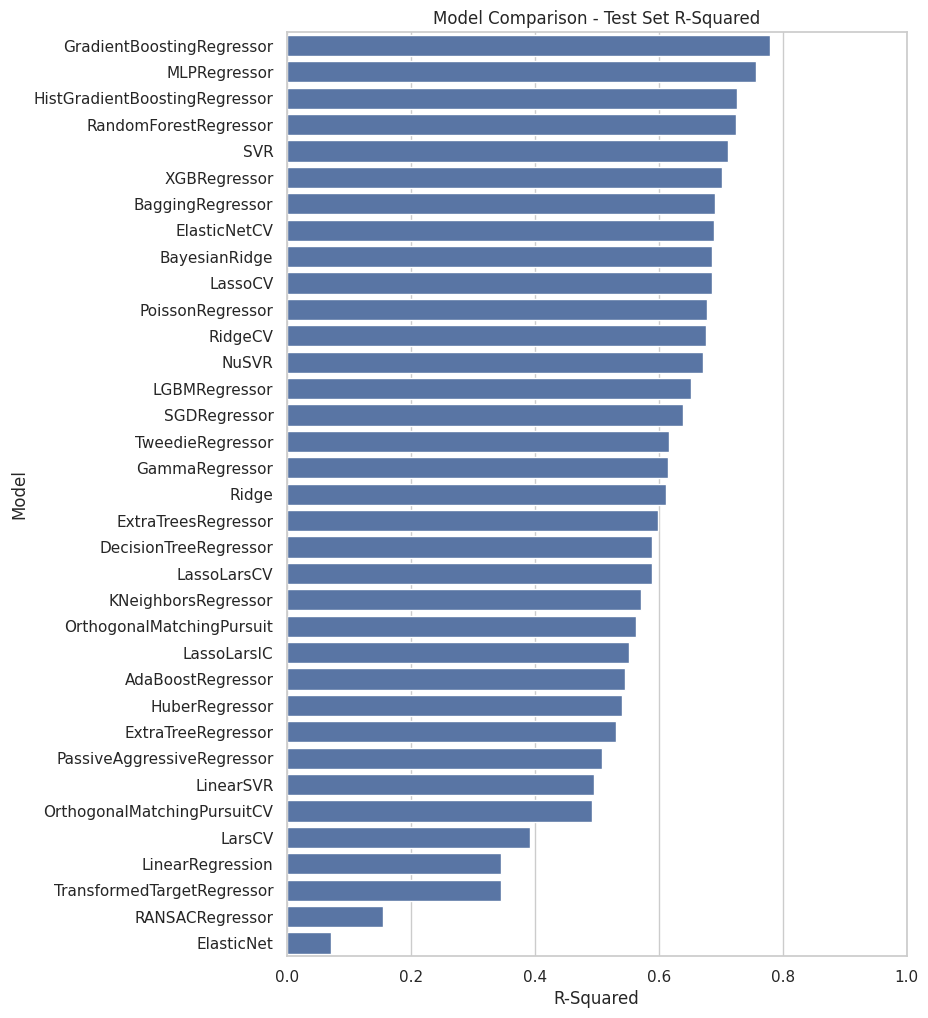

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset index so 'Model' is accessible as a column
train_df = train.reset_index()

# Filter out models with negative R-Squared for a clean plot
train_df_filtered = train_df[train_df['R-Squared'] > 0].sort_values(by="R-Squared", ascending=False)

plt.figure(figsize=(8, 12))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x="R-Squared", y="Model", data=train_df_filtered)
ax.set(xlim=(0, 1.0))
plt.title("Model Comparison - Test Set R-Squared")
plt.show()

In [51]:
# Performance table of the test set (20% subset)
test

""


[(0.0, 1.0)]

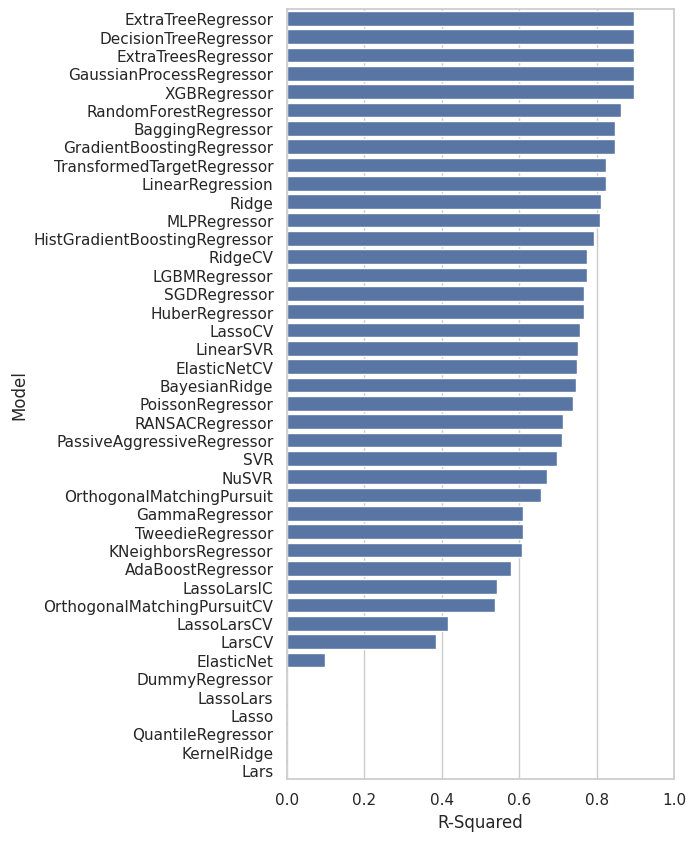

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

#train["R-Squared"] = [0 if i < 0 else i for i in train.iloc[:,0] ]

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=models_train.index, x="R-Squared", data=models_train)
ax.set(xlim=(0, 1))

[(0.0, 10.0)]

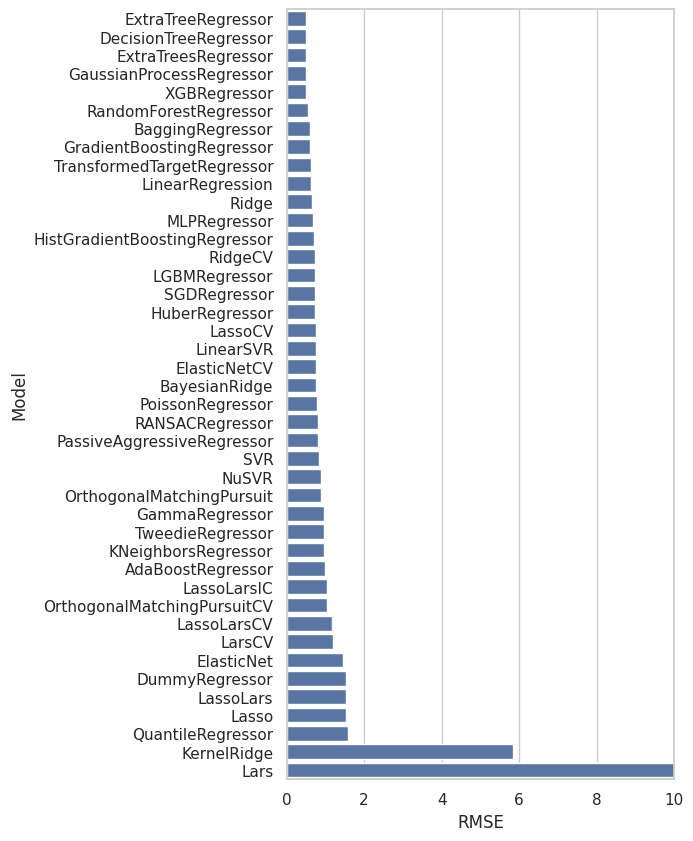

In [53]:
# Bar plot of RMSE values
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=models_train.index, x="RMSE", data=models_train)
ax.set(xlim=(0, 10))

[(0.0, 10.0)]

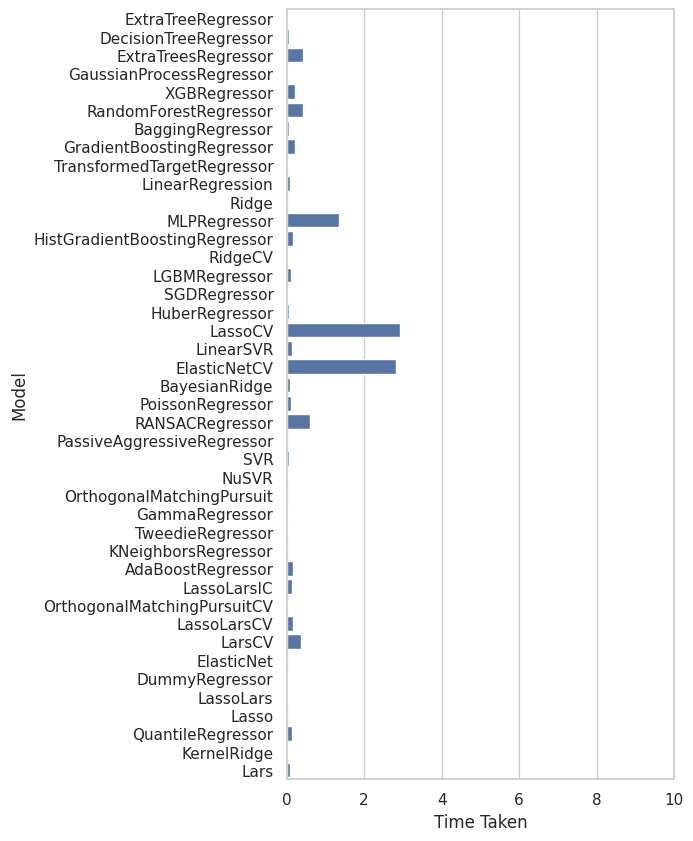

In [54]:
# Bar plot of calculation time
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=models_train.index, x="Time Taken", data=models_train)
ax.set(xlim=(0, 10))